In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [3]:
df = pd.read_csv("C:/Users/Sharath/Desktop/DataScience Intern/week3task3/data/raw_dataset.csv")
df.head()

,age,gender,salary,department,experience,education,city,work_hours,target
0,18,Male,20000,IT,1,Diploma,Chennai,6,0
1,22,Female,25000,HR,2,UG,Chennai,7,0
2,25,Female,30000,IT,3,UG,Bangalore,8,1
3,30,Male,35000,Finance,5,PG,Chennai,9,1
4,35,Male,40000,IT,7,PG,Delhi,10,1


In [4]:
df = pd.get_dummies(df, columns=['gender','department','education','city'])

X = df.drop("target", axis=1)
y = df["target"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [7]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

results = []

In [8]:
def evaluate_model(name, model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    }

In [9]:
for name, model in models.items():
    results.append(evaluate_model(name, model))

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.75,0.5,1.0,0.666667
1,Decision Tree,1.00,1.0,1.0,1.000000
2,Random Forest,1.00,1.0,1.0,1.000000


In [10]:
best_model = results_df.sort_values(by="F1 Score", ascending=False)
best_model

,Model,Accuracy,Precision,Recall,F1 Score
1,Decision Tree,1.00,1.0,1.0,1.000000
2,Random Forest,1.00,1.0,1.0,1.000000
0,Logistic Regression,0.75,0.5,1.0,0.666667


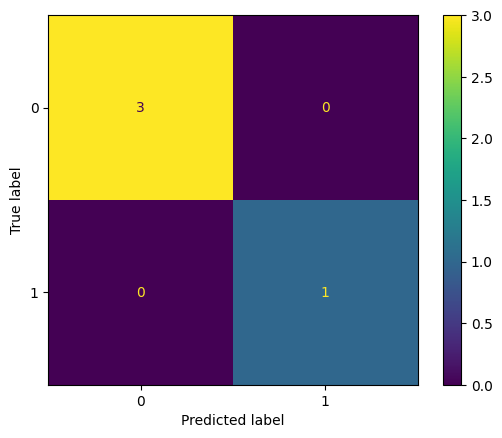

In [11]:
from sklearn.metrics import ConfusionMatrixDisplay

model = RandomForestClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)